Done! Collected 154 transitions.
Done occurred at transition index: 151


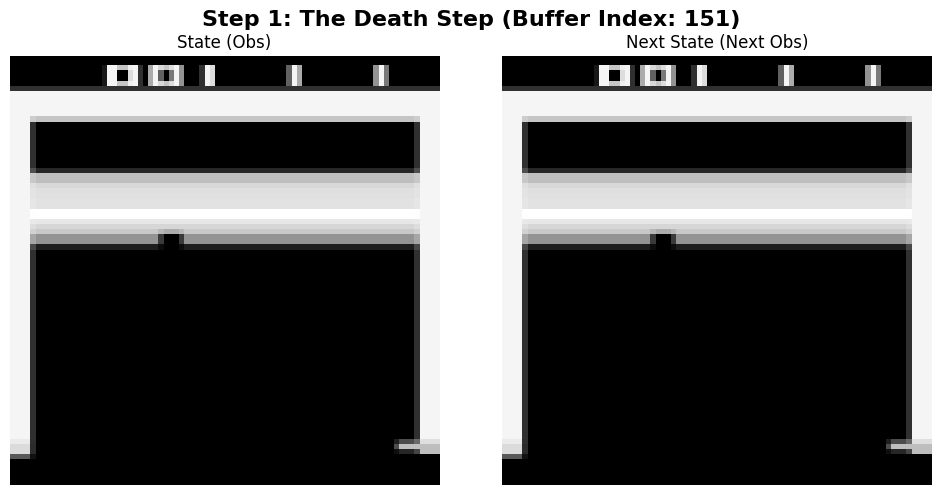

--- Information Flags for Transition 151 ---
Action Taken: 0
Reward:       0.0
Done:         True
Lives:        0
---------------------------------------------


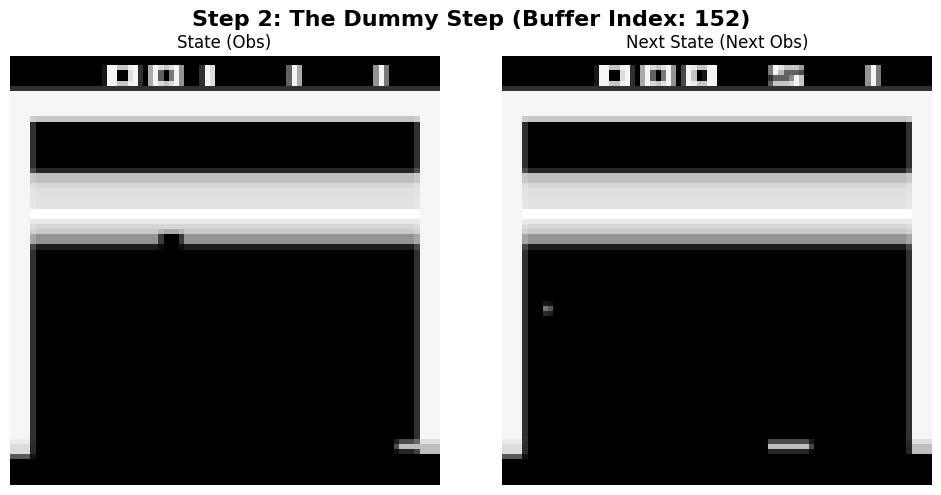

--- Information Flags for Transition 152 ---
Action Taken: 2
Reward:       0.0
Done:         False
Lives:        5
---------------------------------------------


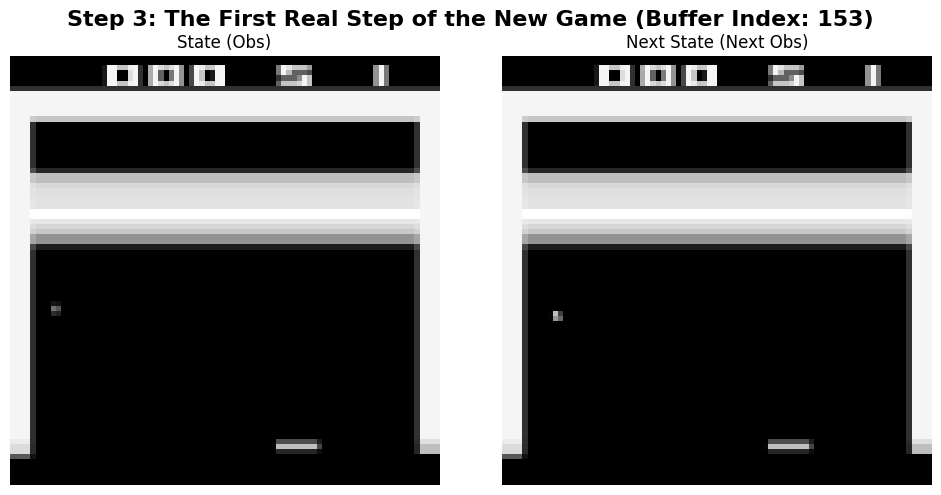

--- Information Flags for Transition 153 ---
Action Taken: 0
Reward:       0.0
Done:         False
Lives:        5
---------------------------------------------


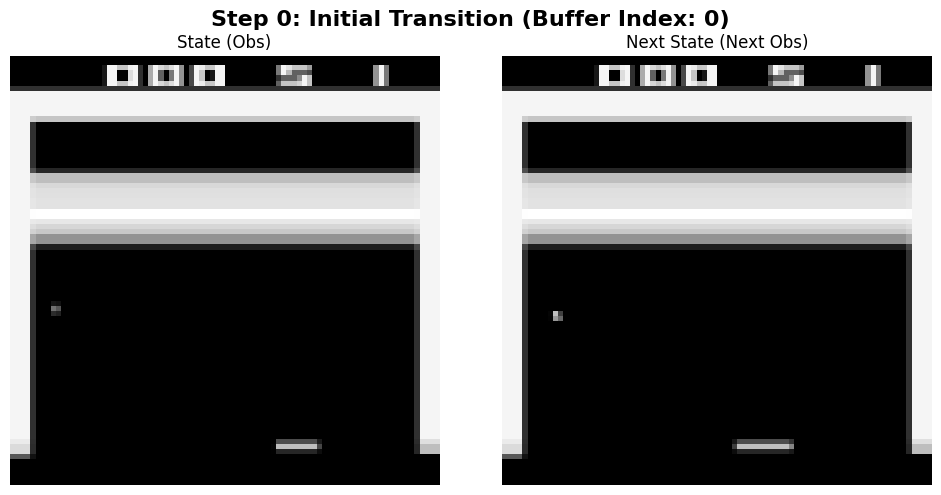

--- Information Flags for Transition 0 ---
Action Taken: 3
Reward:       0.0
Done:         False
Lives:        5
---------------------------------------------


In [ ]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"

import jax
import numpy as np
import matplotlib.pyplot as plt
import envpool

jax.config.update('jax_platform_name', 'cpu')

env = envpool.make(
    "Breakout-v5",
    env_type="gym",
    num_envs=1,
    seed=42,
)

rng = jax.random.PRNGKey(42)

env.num_envs = 1
env.single_action_space = env.action_space
env.single_observation_space = env.observation_space

obs = env.reset()

trajectory = []
done_seen = False
steps_after_done = 0
max_steps = 2000 

print("Collecting trajectory...")
for i in range(max_steps):
    rng, action_rng = jax.random.split(rng)
    actions = jax.random.randint(action_rng, (env.num_envs,), 0, 4)
    actions_np = np.array(actions)
    
    next_obs, raw_rewards, dones, infos = env.step(actions_np)
    
    trajectory.append({
        'step_idx': i,
        'obs': np.array(obs[0]), 
        'next_obs': np.array(next_obs[0]),
        'action': int(actions_np[0]),
        'reward': float(raw_rewards[0]),
        'done': bool(dones[0]),
        'lives': int(infos.get('lives', np.zeros_like(dones))[0])
    })
    
    obs = next_obs
    
    if dones[0]:
        done_seen = True
        
    if done_seen:
        steps_after_done += 1
        
    # Stop collecting 3 steps after we see the done flag
    if steps_after_done >= 3:
        break

print(f"Done! Collected {len(trajectory)} transitions.")

# Find the exact index where the game ended
death_idx = next(i for i, step in enumerate(trajectory) if step['done'])
print(f"Done occurred at transition index: {death_idx}")

def visualize_transition(t, transition, title):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    obs = transition['obs']
    next_obs = transition['next_obs']
    
    # Handle Framestacking (Envpool returns channel-first [4, 84, 84] for Atari by default)
    if obs.shape[0] == 4 or obs.shape[-1] == 4:
        frame_idx = -1 if obs.shape[0] == 4 else 3 # channel first vs last
        o_plot = obs[frame_idx] if obs.shape[0] == 4 else obs[..., frame_idx]
        no_plot = next_obs[frame_idx] if next_obs.shape[0] == 4 else next_obs[..., frame_idx]
    else:
        o_plot, no_plot = obs, next_obs
        
    axes[0].imshow(o_plot, cmap='gray')
    axes[0].set_title(f"State (Obs)")
    axes[0].axis('off')
    
    axes[1].imshow(no_plot, cmap='gray')
    axes[1].set_title(f"Next State (Next Obs)")
    axes[1].axis('off')
    
    plt.suptitle(f"{title} (Buffer Index: {t})", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"--- Information Flags for Transition {t} ---")
    print(f"Action Taken: {transition['action']}")
    print(f"Reward:       {transition['reward']}")
    print(f"Done:         {transition['done']}")
    print(f"Lives:        {transition['lives']}")
    print("-" * 45)

# The transition where done=True
visualize_transition(
    death_idx, 
    trajectory[death_idx], 
    "Step 1: The Death Step"
)

# The transition immediately following done=True (The Dummy Step)
visualize_transition(
    death_idx + 1, 
    trajectory[death_idx + 1], 
    "Step 2: The Dummy Step"
)

# Two transitions after done=True
visualize_transition(
    death_idx + 2, 
    trajectory[death_idx + 2], 
    "Step 3: The First Real Step of the New Game"
)

# Two transitions after done=True
visualize_transition(
    0,
    trajectory[0], 
    "Step 0: Initial Transition"
)